In [ ]:
!pip install langgraph langchain langchain_community langchain_huggingface

In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import TypedDict

In [ ]:
# from google.colab import userdata
# userdata.get('HUGGINGFACEHUB_API_TOKEN')

In [ ]:
# import os
# os.environ["HUGGINGFACEHUB_API_TOKEN"] =

In [5]:
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen3-4B-Instruct-2507",
    task = "text-generation",
)
model = ChatHuggingFace(llm = llm)

In [6]:
class JokeState(TypedDict):
  topic: str
  joke: str
  explanation: str

In [10]:
from ast import parse
def generateJoke(state: JokeState):
  topic = state['topic']
  prompt = PromptTemplate(
      template =
      """Generate a lamest joke on the topic that is funny
      Topic: {topic}
      """,
      input_variables=["topic"]
  )
  parser = StrOutputParser()
  chain = prompt |  model | parser
  response = chain.invoke({"topic": topic})
  return {"joke": response}

In [12]:
def explainJoke(state: JokeState):
  joke = state['joke']
  prompt = PromptTemplate(
      template =
      """Explain the joke that is funny
      Joke: {joke}
      """,
      input_variables=["joke"]
  )
  parser = StrOutputParser()
  chain = prompt |  model | parser
  response = chain.invoke({"joke": joke})
  return {"explanation": response}

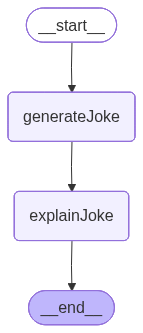

In [15]:
graph = StateGraph(JokeState)
graph.add_node('generateJoke', generateJoke)
graph.add_node('explainJoke', explainJoke)

graph.add_edge(START, 'generateJoke')
graph.add_edge('generateJoke', 'explainJoke')
graph.add_edge('explainJoke', END)

checkPointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkPointer)
workflow

In [16]:
thread_id = '1'
config = {'configurable': {'thread_id': thread_id}}
workflow.invoke({'topic': 'Artificial Intelligence'}, config = config)

{'topic': 'Artificial Intelligence',
 'joke': 'Why did the AI go to therapy?\n\nBecause it had deep learning issues and couldn’t stop overfitting its emotions! 😂\n\n(Also, it just wanted to be *more human*… but only in the data.) 🤖💥',
 'explanation': 'Absolutely! Let\'s break down why this joke is funny — it\'s a clever blend of **tech puns**, **meta humor**, and **a playful twist on real-world AI concepts**.\n\n---\n\n### 🎯 The Joke:\n> *"Why did the AI go to therapy?  \n> Because it had deep learning issues and couldn’t stop overfitting its emotions! 😂  \n> (Also, it just wanted to be *more human*… but only in the data.) 🤖💥"*\n\n---\n\n### 🔍 Why It’s Funny — Step by Step:\n\n#### 1. **"Deep learning issues"** → A tech pun\n- "Deep learning" is a real AI concept where neural networks learn from data in layered, complex ways.\n- Saying the AI has "deep learning issues" is a clever twist — it sounds like it\'s having emotional or psychological problems, just like humans might.\n- This c

In [26]:
thread_id = '2'
config2 = {'configurable': {'thread_id': thread_id}}
workflow.invoke({'topic': 'Summer'}, config = config2)

{'topic': 'Summer',
 'joke': "Why did the summer go to therapy?  \nBecause it had *too many sunblocks* and couldn’t handle the *heat of the moment*! 😂☀️  \n\n(And yes, it's technically a *lame* joke — but also kind of valid for a sunny day.)",
 'explanation': 'Ah, the joke "Why did the summer go to therapy? Because it had *too many sunblocks* and couldn’t handle the *heat of the moment*!" — while admittedly a bit of a stretch — is funny in a playful, punny, and slightly absurd way. Let’s break down why it works (despite being "lame" as the narrator says):\n\n---\n\n### 1. **Pun on "sunblocks" and "therapy"**\nThe humor comes from a **double meaning**:\n- "Sunblocks" are literal sunscreens people use to protect themselves from UV rays.\n- But "sunblocks" also sounds like a **metaphor for emotional or psychological blocks** — like mental barriers or defense mechanisms in therapy.\n\nSo when summer says it had "too many sunblocks," it\'s a pun — implying it\'s *overprotected* or *emotiona

In [25]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'Elon Musk', 'joke': 'Why did Elon Musk bring a ladder to the party?\n\nBecause he heard the stairs were *Tesla*ing! 🚗⚡😄\n\n*(Bonus points if you didn’t know Tesla doesn’t even have stairs — it just has a lot of hype and a very steep learning curve.)* 😂', 'explanation': 'The joke is a clever play on words and puns that blends technology, pop culture, and a bit of absurdity — all typical of a good tech-related humor.\n\nLet’s break it down:\n\n**Joke:** *"Why did Elon Musk bring a ladder to the party? Because he heard the stairs were Tesla-ing!"*\n\n### 1. **"Tesla-ing" as a pun**\n- The word *"Tesla-ing"* is a pun on the brand **Tesla** and the verb **"to Tesla"** (as in "to Tesla" — like "to go Tesla").\n- It sounds like *"stepping"* or *"stair-ing"*, playing on *stairs* and *Tesla*.\n- So, "the stairs were Tesla-ing" sounds like "the stairs were *stepping*," but with a twist — like Elon is saying the stairs are *Tesla*-ing, meaning they\'re *hyped*, *el

In [29]:
history = list(workflow.get_state_history(config2))
len(history)

8

In [32]:
for i in history:
  print(i)
  print('---')

StateSnapshot(values={'topic': 'Summer', 'joke': "Why did the summer go to therapy?  \nBecause it had *too many sunblocks* and couldn’t handle the *heat of the moment*! 😂☀️  \n\n(And yes, it's technically a *lame* joke — but also kind of valid for a sunny day.)", 'explanation': 'Ah, the joke "Why did the summer go to therapy? Because it had *too many sunblocks* and couldn’t handle the *heat of the moment*!" — while admittedly a bit of a stretch — is funny in a playful, punny, and slightly absurd way. Let’s break down why it works (despite being "lame" as the narrator says):\n\n---\n\n### 1. **Pun on "sunblocks" and "therapy"**\nThe humor comes from a **double meaning**:\n- "Sunblocks" are literal sunscreens people use to protect themselves from UV rays.\n- But "sunblocks" also sounds like a **metaphor for emotional or psychological blocks** — like mental barriers or defense mechanisms in therapy.\n\nSo when summer says it had "too many sunblocks," it\'s a pun — implying it\'s *overprot

### Fault Tolerance

In [38]:
import time
class CrashState(TypedDict):
  input: str
  step1: str
  step2: str
  step3: str

In [39]:
def firstStep(state: CrashState) -> CrashState:
  print("Step 1 Executed")
  return {"step1": "done", "input": state['input']}

def sencondStep(state: CrashState) -> CrashState:
  print("Delay in step 2, manually interrupt from notebook")
  time.sleep(30)
  return {"step2": "done"}

def thirdStep(state: CrashState) -> CrashState:
  print("Step 3 Executed")
  return {"step3": "done"}

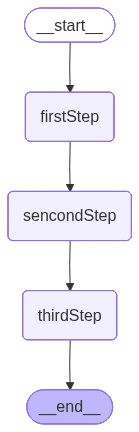

In [40]:
faultyGraph = StateGraph(CrashState)
faultyGraph.add_node('firstStep', firstStep)
faultyGraph.add_node('sencondStep', sencondStep)
faultyGraph.add_node('thirdStep', thirdStep)

faultyGraph.add_edge(START, 'firstStep')
faultyGraph.add_edge('firstStep', 'sencondStep')
faultyGraph.add_edge('sencondStep', 'thirdStep')
faultyGraph.add_edge('thirdStep', END)

cp = InMemorySaver()
wf = faultyGraph.compile(checkpointer=cp)
wf

In [ ]:
try:
  print("Running Graph, manually interrupt during Step 2")
  config = {'configurable: {"thread_id" : "1"}'}
  wf.invoke({"input": "start"}, config = config)
except KeyboardInterrupt:
  print("Manually Interupted")

### Fault Tolerance Using CheckPoint ID

In [ ]:
history = list(workflow.get_state_history(config2))
for i in history:
  print(i)

In [ ]:
workflow.get_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f16e41d-de59-66c9-8002-4f4043ea233b"}})

In [ ]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f16e41d-de59-66c9-8002-4f4043ea233b"}})